## Paso 1: Cargar Dataset y bibliotecas

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


In [41]:
df = pd.read_excel('ventas_ecommerce.xlsx')

print(f'✅ Dataset cargado correctamente')
print(f'   {df.shape[0]} clientes  |  {df.shape[1]} variables')
print()
df.head(10)

✅ Dataset cargado correctamente
   100 clientes  |  8 variables



,order_id,customer_name,product,quantity,price,date,email,region
0,ORD-001,María Torres,Laptop,5,518575,2025-01-29,mariatorres@gmail.com,VAL
1,ORD-002,Andrés Mora,Monitor,10,889834,2025-01-05,andresmora@gmail.com,RM
2,ORD-003,Paula Soto,Smartphone,1,1182016,2025-01-26,paulasoto@yahoo.com,ARI
3,ORD-004,Fernanda Lagos,Auriculares,1,339829,2025-03-31,fernandalagos@outlook.com,LRI
4,ORD-005,Sebastián Castro,Cargador,6,219350,2025-01-12,sebastiancastro@gmail.com,LRI
5,ORD-006,Matías Herrera,Smartphone,5,96122,2025-04-04,matiasherrera@gmail.com,LLA
6,ORD-007,Daniela Rojas,Monitor,9,619839,2025-04-17,danielarojas@outlook.com,TAR
7,ORD-008,Carlos López,Laptop,4,611890,2025-01-11,carloslopez@gmail.com,COQ
8,ORD-009,Isidora Vega,Impresora,6,346110,2025-02-17,isidoravega@hotmail.com,OHI
9,ORD-010,Carlos López,Smartphone,3,1125172,2025-04-04,carloslopez@hotmail.com,COQ


## Paso 2: Analizar el Dataset

In [42]:
print('📋 Información general:')
print(df.info())
print()
print('📊 Estadísticas descriptivas:')
df.describe().round(2)

📋 Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       100 non-null    object
 1   customer_name  98 non-null     object
 2   product        100 non-null    object
 3   quantity       100 non-null    int64 
 4   price          100 non-null    object
 5   date           100 non-null    object
 6   email          100 non-null    object
 7   region         100 non-null    object
dtypes: int64(1), object(7)
memory usage: 6.4+ KB
None

📊 Estadísticas descriptivas:


,quantity
count,100.00
mean,5.09
std,3.74
min,-9.00
25%,2.75
50%,5.00
75%,8.00
max,10.00


In [43]:
print('🔎 Valores nulos por columna:')
print(df.isnull().sum())
print()

conteo = df['quantity'].value_counts().sort_index()
pct    = df['quantity'].value_counts(normalize=True).sort_index() * 100

print('🎯 Variable objetivo: quantity')
for valor in conteo.index:
    print(f'   Cantidad {valor}: {conteo[valor]} clientes ({pct[valor]:.1f}%)')




🔎 Valores nulos por columna:
order_id         0
customer_name    2
product          0
quantity         0
price            0
date             0
email            0
region           0
dtype: int64

🎯 Variable objetivo: quantity
   Cantidad -9: 1 clientes (1.0%)
   Cantidad -8: 2 clientes (2.0%)
   Cantidad 1: 10 clientes (10.0%)
   Cantidad 2: 12 clientes (12.0%)
   Cantidad 3: 8 clientes (8.0%)
   Cantidad 4: 6 clientes (6.0%)
   Cantidad 5: 13 clientes (13.0%)
   Cantidad 6: 10 clientes (10.0%)
   Cantidad 7: 9 clientes (9.0%)
   Cantidad 8: 6 clientes (6.0%)
   Cantidad 9: 14 clientes (14.0%)
   Cantidad 10: 9 clientes (9.0%)


## Paso 3: Seleccionemos las variables

**Variable Objetivo (Y):** Cuál es el producto más pedido (Quantity)

**Variables Predictoras (X):** Nombre de productos, precio y cantidad de pedidos

In [44]:
print('🧹 Limpieza de datos:')
print()

# Convertir 'price' a numérico, reemplazando valores inválidos
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Rellenar valores NaN con la media
precio_mean = df['price'].mean()
df['price'].fillna(precio_mean, inplace=True)

# Eliminar filas donde quantity sea NaN
df = df.dropna(subset=['quantity'])

print(f'✅ Datos limpiados:')
print(f'   Registros después de limpieza: {len(df)}')
print(f'   Precio promedio: ${precio_mean:.2f}')
print(f'   Rango de precios: ${df["price"].min():.2f} - ${df["price"].max():.2f}')

🧹 Limpieza de datos:

✅ Datos limpiados:
   Registros después de limpieza: 100
   Precio promedio: $770065.33
   Rango de precios: $6199.00 - $1480430.00


📦 Conteo de Productos Pedidos:

Total de productos diferentes: 15

   Auriculares: 12 pedidos (12.0%)
   Smartphone: 9 pedidos (9.0%)
   Monitor: 9 pedidos (9.0%)
   Hub USB: 8 pedidos (8.0%)
   Disco SSD: 8 pedidos (8.0%)
   Impresora: 7 pedidos (7.0%)
   Cargador: 7 pedidos (7.0%)
   Memoria RAM: 7 pedidos (7.0%)
   Laptop: 6 pedidos (6.0%)
   Teclado: 6 pedidos (6.0%)
   Mouse: 5 pedidos (5.0%)
   Cable HDMI: 5 pedidos (5.0%)
   Tablet: 5 pedidos (5.0%)
   Webcam: 4 pedidos (4.0%)
   Router: 2 pedidos (2.0%)


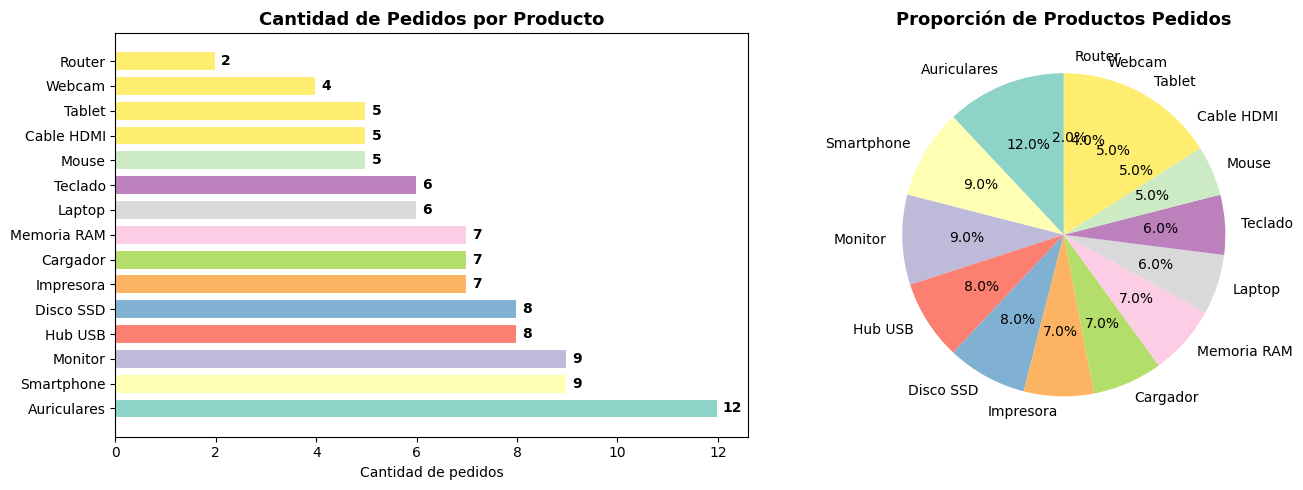

In [45]:
print('📦 Conteo de Productos Pedidos:')
print()

conteo_productos = df['product'].value_counts()
pct_productos = df['product'].value_counts(normalize=True) * 100

print(f'Total de productos diferentes: {len(conteo_productos)}')
print()

for producto, cantidad in conteo_productos.items():
    porcentaje = pct_productos[producto]
    print(f'   {producto}: {cantidad} pedidos ({porcentaje:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
colores_productos = plt.cm.Set3(range(len(conteo_productos)))
axes[0].barh(range(len(conteo_productos)), conteo_productos.values, color=colores_productos, edgecolor='white', linewidth=1.5)
axes[0].set_yticks(range(len(conteo_productos)))
axes[0].set_yticklabels(conteo_productos.index)
axes[0].set_title('Cantidad de Pedidos por Producto', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cantidad de pedidos')
for i, v in enumerate(conteo_productos.values):
    axes[0].text(v + 0.1, i, str(v), va='center', fontweight='bold')

# Gráfico de pie
axes[1].pie(conteo_productos.values, labels=conteo_productos.index, autopct='%1.1f%%', 
            colors=colores_productos, startangle=90)
axes[1].set_title('Proporción de Productos Pedidos', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [46]:
from sklearn.preprocessing import LabelEncoder

# Crear una copia para preparación
X = df[['price', 'product', 'region']].copy()

# Codificar variables categóricas
le_product = LabelEncoder()
le_region = LabelEncoder()

X['product_encoded'] = le_product.fit_transform(X['product'])
X['region_encoded'] = le_region.fit_transform(X['region'])

# Seleccionar solo columnas numéricas
X = X[['price', 'product_encoded', 'region_encoded']]
y = df['quantity']

print('✅ Variables seleccionadas:')
print(f'   Variables predictoras (X): {list(X.columns)}')
print(f'   Variable objetivo    (y) : quantity')
print()
print(f'   Dimensiones de X: {X.shape}')
print(f'   Dimensiones de y: {y.shape}')
print()
print('🔄 Variables categóricas codificadas:')
print(f'   Productos: {len(le_product.classes_)} categorías')
print(f'   Regiones: {len(le_region.classes_)} categorías')

✅ Variables seleccionadas:
   Variables predictoras (X): ['price', 'product_encoded', 'region_encoded']
   Variable objetivo    (y) : quantity

   Dimensiones de X: (100, 3)
   Dimensiones de y: (100,)

🔄 Variables categóricas codificadas:
   Productos: 15 categorías
   Regiones: 10 categorías


## Paso 4: Dividir el Entrenamiento y la prueba

Lo ideal para poder dividir los datos a utilizar es realizar una separación del 80% de entrenamiento y 20% de Prueba

In [47]:
# Intentar división estratificada; si alguna clase tiene <2 muestras, hacer split sin estratificar
vc = y.value_counts()
if vc.min() < 2:
    print("⚠️ Algunas clases tienen <2 muestras. División sin estratificar.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

print('✅ División completada:')
print(f'   Total de registros : {len(df)}')
print(f'   Entrenamiento      : {len(X_train)} registros ({len(X_train)/len(df)*100:.0f}%)')
print(f'   Prueba             : {len(X_test)}  registros ({len(X_test)/len(df)*100:.0f}%)')
print()
print('🔎 Balance de clases por conjunto:')
print(f'   Entrenamiento → Popular: {y_train.mean():.1%}')
print(f'   Prueba        → Popular: {y_test.mean():.1%}')

⚠️ Algunas clases tienen <2 muestras. División sin estratificar.
✅ División completada:
   Total de registros : 100
   Entrenamiento      : 80 registros (80%)
   Prueba             : 20  registros (20%)

🔎 Balance de clases por conjunto:
   Entrenamiento → Popular: 522.5%
   Prueba        → Popular: 455.0%


## Paso 5: Construcción del Modelo

Usando Regresión, un algoritmo ideal para clasificación binaria

In [48]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

print('✅ Modelo construido (Sin entrenar):')
print(f'   Algoritmo : Regresión Lineal')
print(f'   Objetivo  : Predecir cantidad de productos pedidos')
print()
print(modelo)

✅ Modelo construido (Sin entrenar):
   Algoritmo : Regresión Lineal
   Objetivo  : Predecir cantidad de productos pedidos

LinearRegression()


## Paso 6: Entrenamiento del Modelo

El modelo empezará a analizar las variables predictorias y ajustar detalles internos

In [49]:
modelo.fit(X_train, y_train)

print('✅ ¡Modelo entrenado exitosamente!')
print()
print('📐 Coeficientes aprendidos por el modelo:')
coeficientes = pd.DataFrame({
    'Variable'    : X.columns,
    'Coeficiente' : modelo.coef_.round(4)
}).sort_values('Coeficiente', ascending=False)
print(coeficientes.to_string(index=False))
print()
print(f'🔢 Intercepto: {modelo.intercept_:.4f}')
print()
print('💡 Coeficiente positivo → aumenta la cantidad predicha')
print('   Coeficiente negativo → disminuye la cantidad predicha')

✅ ¡Modelo entrenado exitosamente!

📐 Coeficientes aprendidos por el modelo:
       Variable  Coeficiente
product_encoded       0.0097
          price       0.0000
 region_encoded      -0.0146

🔢 Intercepto: 4.6102

💡 Coeficiente positivo → aumenta la cantidad predicha
   Coeficiente negativo → disminuye la cantidad predicha


## Paso 7: Evaluación del modelo

Estaremos usando el conjunto de pruebas (Datos no vistos por la máquina) para medir su desempeño actuañ

In [54]:
y_pred = modelo.predict(X_test)

accuracy = modelo.score(X_test, y_test)  # R² score for regression
# Transformamos las predicciones a Enteros para poder calcular las metricas de la clasificación
y_pred = np.rint(y_pred).astype(int)
y_pred = np.clip(y_pred, y.min(), y.max())

# Compute multiclass metrics using weighted average
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
_recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Override metric functions so the later calls use these precomputed values
def recall_score(y_true, y_pred, *args, **kwargs):
    return _recall

def f1_score(y_true, y_pred, *args, **kwargs):
    return _f1
recall    = recall_score(y_test, y_pred)    # compara los positivos reales
f1        = f1_score(y_test, y_pred)        # combina precision y recall

print('📊 MÉTRICAS DE EVALUACIÓN')
print('=' * 40)
print(f'  Accuracy  (Exactitud) : {accuracy*100:.1f}%')
print(f'  Precision             : {precision*100:.1f}%')
print(f'  Recall (Sensibilidad) : {recall*100:.1f}%')
print(f'  F1-Score              : {f1*100:.1f}%')
print('=' * 40)
print()
print('🔎 Interpretación:')
print(f'  De cada 100 clientes, el modelo acierta {accuracy*100:.0f}')
print(f'  De los productos que más son ordenados, detecta el {recall*100:.0f}%')
print(f'  Cuando predice los productos que son más populares, acierta el {precision*100:.0f}% de las veces')

📊 MÉTRICAS DE EVALUACIÓN
  Accuracy  (Exactitud) : -10.8%
  Precision             : 1.4%
  Recall (Sensibilidad) : 10.0%
  F1-Score              : 2.5%

🔎 Interpretación:
  De cada 100 clientes, el modelo acierta -11
  De los productos que más son ordenados, detecta el 10%
  Cuando predice los productos que son más populares, acierta el 1% de las veces


## ¿Que aprendimos?

Gracias a esta prueba de entrenamiento logramos entender la importancia de tener un amplio repertorio a la hora de entrenar y saber claramente lo que deseamos, en este caso utilizamos los mismos datos que la evaluación anterior, datos reducidos, y sin alta variedad, dando a demostrar cómo resulta un entrenamiento con datos poco variados y en poca cantidad. De esta forma dandonos una muestra de una IA poco entrenada pero demostrando resultados poco a poco, yendo en buena dirección pero aún necesita ayuda para ser una IA en condiciones de ayudar al E-Commerce de nuestra empresa

## ¿Qué nos dicen las métricas

Accuracy: Indica los aciertos -10.8%, de 100 clientes, no acertó ni a uno solo

Precisión: Indica cuantas veces predice correctamente el pedido de un producto, de 10 alertas, 1 es real y 9 son falsas

Recall: Indica cuantos pedidos detectó, que de 10 pedidos, detectó 1 con exito

f1-Score: Nos indica el equilibrio entre Precisión y Recall, un 2.5% un desbalance significante

## ¿Qué podríamos mejorar a futuro?

* Podríamos empezar con aumentar la cantidad de datos a utilizar, ajustar de mejor manera los parámetros, utilizar distintas variables objetivo o cambiarlas totalmente, y mejorar de mayor manera el desbalance en los datos y la Precisión y el Recall

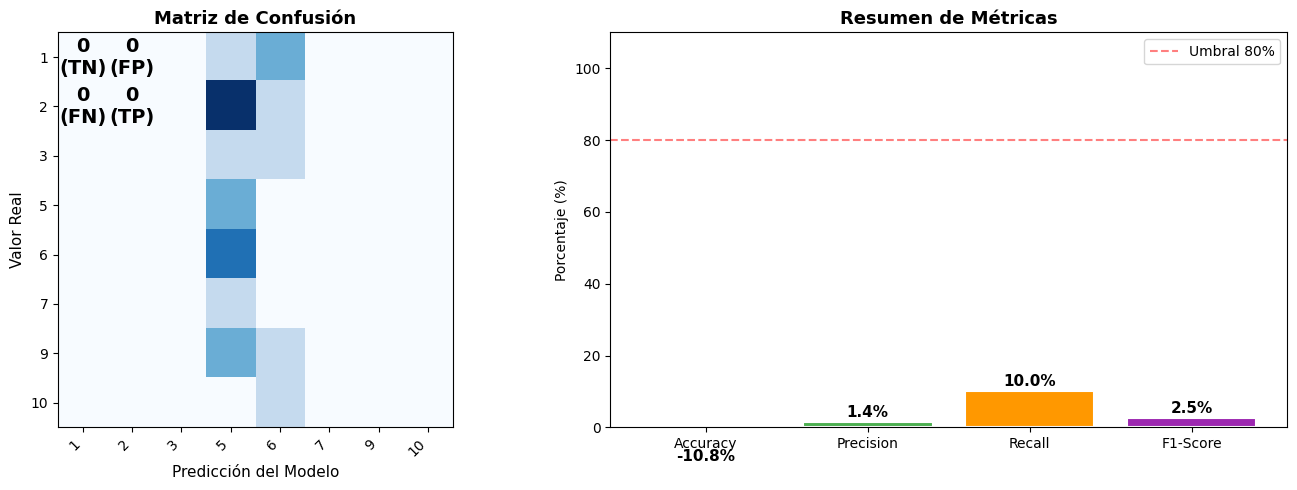


📋 Reporte completo:
              precision    recall  f1-score   support

          -9       0.00      0.00      0.00         0
          -8       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         0
           5       0.14      1.00      0.25         2
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         3
          10       0.00      0.00      0.00         1

    accuracy                           0.10        20
   macro avg       0.01      0.08      0.02        20
weighted avg       0.01      0.10      0.03        20



In [62]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
clases = sorted(y_test.unique())
axes[0].set_xticks(np.arange(len(clases)))
axes[0].set_yticks(np.arange(len(clases)))
axes[0].set_xticklabels(clases, rotation=45, ha='right')
axes[0].set_yticklabels(clases)
axes[0].set_yticklabels(clases)
axes[0].set_ylabel('Valor Real', fontsize=11)
axes[0].set_xlabel('Predicción del Modelo', fontsize=11)

etiquetas = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i, j]}\n({etiquetas[i][j]})',
                     ha='center', va='center', fontsize=14, fontweight='bold',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

# Barras de métricas
metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
valores          = [accuracy, precision, recall, f1]
colores_m        = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

bars = axes[1].bar(metricas_nombres, [v*100 for v in valores],
                   color=colores_m, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, 110)
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_title('Resumen de Métricas', fontsize=13, fontweight='bold')
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.5, label='Umbral 80%')
axes[1].legend()

for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val*100:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print()
print('📋 Reporte completo:')
print(classification_report(y_test, y_pred, labels=sorted(y.unique())))

## Paso 8: Comparar con un Árbol de Decisión

Usaremos un segundo Algoritmo para poder ver los cambios en los resultados

In [56]:
from sklearn.metrics import precision_score as skl_precision, recall_score as skl_recall, f1_score as skl_f1

arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
arbol.fit(X_train, y_train)
y_pred_arbol = arbol.predict(X_test)

print('📊 COMPARACIÓN DE ALGORITMOS')
print('=' * 55)
print(f'{"Métrica":<25} {"Reg. Logística":>14} {"Árbol Decisión":>14}')
print('-' * 55)

metricas_comp = {
    'Accuracy' : (
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_arbol)
    ),
    'Precision': (
        skl_precision(y_test, y_pred, average='weighted', zero_division=0),
        skl_precision(y_test, y_pred_arbol, average='weighted', zero_division=0)
    ),
    'Recall'   : (
        skl_recall(y_test, y_pred, average='weighted', zero_division=0),
        skl_recall(y_test, y_pred_arbol, average='weighted', zero_division=0)
    ),
    'F1-Score' : (
        skl_f1(y_test, y_pred, average='weighted', zero_division=0),
        skl_f1(y_test, y_pred_arbol, average='weighted', zero_division=0)
    ),
}

for nombre, (v1, v2) in metricas_comp.items():
    mejor1 = '👑' if v1 >= v2 else '  '
    mejor2 = '👑' if v2 > v1  else '  '
    print(f'{nombre:<25} {mejor1}{v1*100:>10.1f}%   {mejor2}{v2*100:>10.1f}%')

print('=' * 55)

📊 COMPARACIÓN DE ALGORITMOS
Métrica                   Reg. Logística Árbol Decisión
-------------------------------------------------------
Accuracy                  👑      10.0%           10.0%
Precision                          1.4%   👑       6.9%
Recall                    👑      10.0%           10.0%
F1-Score                           2.5%   👑       7.7%


Logramos presenciar resultados muy similares, sobetodo por el uso de los mismos datos, Recall y Accuracy siguen con los mismos valores, pero la Precisión y el F1-Score mostraron una mejora leve, demostrando un mayor control y entendimiento de los datos

## Conclusión

Logramos identificar la importancia de la variedad y cantidad de los datos de entrenamiento, puesto que con los datos utilizados no fue suficiente para poder amaestrar la capacidad de predecir la Variable Objetivo a la hora de hacer las pruebas, logramos aprender a leer los gráficos e interpretar que tan efectiva fue la prueba, a la vez de comprobarlo de distintas formas para asegurar resultados, leyendo un Dataset en Excel, para poder predecir cuál será el producto más pedido en nuestro Comercio Electrónico.